In [3]:
import os, copy, h5py
import astropy.units as u
from astropy.cosmology import Planck13, z_at_value
import numpy as np
import pandas as pd
from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import generate_boilerplate_outputfile, extract_unit_dict, temp_dir
from compas_python_utils.cosmic_integration.ClassCOMPAS import COMPASData
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023, madau_dickinson_sfr
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022, compas_log_skew_normal_distribution_metallicity_distribution
from syntheticstellarpopconvolve.general_functions import calculate_bincenters, calculate_bin_edges
from syntheticstellarpopconvolve.cosmology_utils import lookback_time_to_redshift
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict
import matplotlib.pyplot as plt
from population_vis import get_formation_efficiency
import time
import warnings
import scipy
from scipy import stats
from get_ZdepSFRD import skew_metallicity_distribution
import pickle
import h5py as h5

[0.25 0.75 1.25 1.75 2.25 2.75 3.25 3.75 4.25 4.75 5.25 5.75 6.25 6.75
 7.25 7.75 8.25 8.75 9.25 9.75]
(19,)
(19,)


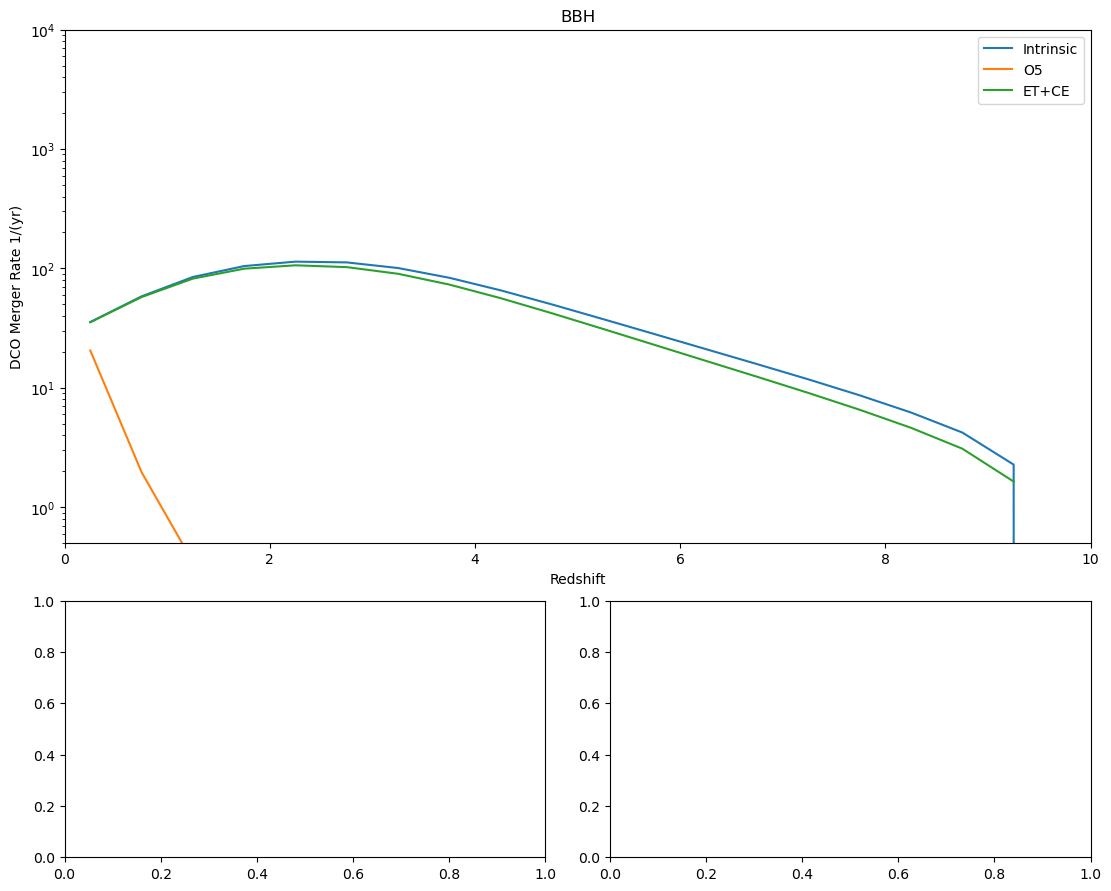

In [13]:
form_fig = plt.figure(constrained_layout=True, figsize=(11, (8/10)*11))
form_ax = form_fig.subplot_mosaic([
    ['Top', 'Top'],
    ['Left', 'Right']
], height_ratios=[2,1])
# first reproduce the intrinsic line

def plot_with_cut(fname, ax, redshifts, intrinsic_rate, label, comoving_volume):
    snr_weights = np.load(fname)
    scale = np.sum(snr_weights, axis=1)/(snr_weights.shape[1])
    print(scale.shape)
    p_line = intrinsic_rate*scale*comoving_volume
    ax.plot(
        redshifts,
        p_line,
        label=label
    )
    # print(intrinsic['redshifts'])
    ax.set_xlabel('Redshift')
    ax.set_ylabel('DCO Merger Rate 1/(yr)')
    ax.set_xlim(0, 10)
    ax.set_ylim(0.5, 10e3)
    ax.legend()
    ax.set_yscale('log')

def plot_subpopulation(pop_type, loc):
    # with open(f'./fiducial_{pop_type}.pkl', 'rb') as p:
    # intrinsic = pickle.load(p)
    fci_out = h5.File('/Volumes/Elements/Boesky_alpha0.1beta0.5.h5')
    rate_key = 'Rates_mu00.025_muz-0.052_alpha-1.88_sigma01.15_sigmaz0.0477'
    global form_ax
    ax = form_ax[loc]
    comoving_volume = 1#Planck13.comoving_volume(intrinsic['redshifts']).to(u.Gpc**3).value
    # print(comoving_volume.shape)
    reds_bin_centers = (fci_out[rate_key]['redshifts'][1:]+fci_out[rate_key]['redshifts'][:-1])/2
    print(reds_bin_centers)
    intrinsic_rate = np.sum(fci_out[rate_key]['merger_rate'], axis=0)*comoving_volume
    ax.plot(reds_bin_centers, intrinsic_rate, label='Intrinsic')
    # now also plot the SNR cuts
    plot_with_cut(f'{pop_type}_O5_8.npy', ax, reds_bin_centers[:-1], intrinsic_rate[:-1], 'O5', comoving_volume)
    # plot_with_cut(f'{pop_type}_O4_8.npy', ax, intrinsic, 'O4', comoving_volume)
    plot_with_cut(f'{pop_type}_ET_CE_8.npy', ax, reds_bin_centers[:-1], intrinsic_rate[:-1], 'ET+CE', comoving_volume)
    ax.set_title(pop_type)
    # p.close()
plot_subpopulation('BBH', 'Top')
# plot_subpopulation('BHNS', 'Left')
# plot_subpopulation('BNS', 'Right')